# الدرس الثالث: (الفأرة كأداة رسم):

هنا ستتعلم كيفية استخدام التابع :

`()cv2.setMouseCallback`

##  مثال مبسط:

هنا سننشأ تطبيق بسيط يرسم دائرة حيثما نقرت بالفأرة على الشاشة ..
وبالتالي سننشأ تابع استدعاء مرتبط باحداث الفأرة
`mouse events`
وهذه تعد اي شيء مرتبط بالفأرة ,مثل ضغط الزر الايسر أو رفع الضغط أو ضغطه مرتين الخ ... 
وتعطينا الاحداثيات 
(x,y)
لكل حدث منها , ومع هذه الاحداث والمواضع يمكننا القيام باي شيء نرغب به ...


ولمعرفة الاحداث المتوفرة , يمكن كتابة:

In [1]:
import cv2
events = [i for i in dir(cv2) if 'EVENT' in i]
for a in events :
    print a

EVENT_FLAG_ALTKEY
EVENT_FLAG_CTRLKEY
EVENT_FLAG_LBUTTON
EVENT_FLAG_MBUTTON
EVENT_FLAG_RBUTTON
EVENT_FLAG_SHIFTKEY
EVENT_LBUTTONDBLCLK
EVENT_LBUTTONDOWN
EVENT_LBUTTONUP
EVENT_MBUTTONDBLCLK
EVENT_MBUTTONDOWN
EVENT_MBUTTONUP
EVENT_MOUSEMOVE
EVENT_RBUTTONDBLCLK
EVENT_RBUTTONDOWN
EVENT_RBUTTONUP


ولانشاء استدعاء للفأرة هناك صيغة واحدة ,و الذي يختلف هو اثر التابع , لذلك التابع هنا يقوم بأمر واحد , وهو الرسم 

كما يوضح الكود التالي:


In [2]:
import cv2
import numpy as np

# mouse callback function
def draw_circle(event,x,y,flags,param):
    if event == cv2.EVENT_LBUTTONDBLCLK:
        cv2.circle(img,(x,y),100,(255,0,0),-1)
# Create a black image, a window and bind the function to window
img = np.zeros((512,512,3), np.uint8)
cv2.namedWindow('image')
cv2.setMouseCallback('image',draw_circle)

while(1):
    cv2.imshow('image',img)
    if cv2.waitKey(20) == 27:
        break
cv2.destroyAllWindows()

## مثال اوضح :
الان لتطبيق افضل , وفيه نرسم اما مستطيلا او دائرة بناء على الحالة المختارة , ولذلك تابع استدعاء صورتنا لديه شقين , واحد لرسم المستطيل والاخر لرسم الدائرة , وهذا المثال قد يكون مفيداً حقاً لبعض التطبيقات كتتبع الاجسام , وتقطيع الصورة ...


In [3]:
import cv2
import numpy as np

drawing = False # true if mouse is pressed
mode = True # if True, draw rectangle. Press 'm' to toggle to curve
ix,iy = -1,-1

# mouse callback function
def draw_circle(event,x,y,flags,param):
    global ix,iy,drawing,mode
    
    if event == cv2.EVENT_LBUTTONDOWN:
        drawing = True
        ix,iy = x,y
    elif event == cv2.EVENT_MOUSEMOVE:
        if drawing == True:
            if mode == True:
                cv2.rectangle(img,(ix,iy),(x,y),(0,255,0),-1)
            else:
                cv2.circle(img,(x,y),5,(0,0,255),-1)
                
    elif event == cv2.EVENT_LBUTTONUP:
        drawing = False
        if mode == True:
            cv2.rectangle(img,(ix,iy),(x,y),(0,255,0),-1)
        else:
            cv2.circle(img,(x,y),5,(0,0,255),-1)


بالسابق عرفنا التابع , وفيما يلي سنربطه مع تابع استدعاء الفأرة , وكذلك نسند للحرف 
`m` كمتغير شامل global
 التغيير من رسم مستطيل لرسم دائرة او العكس.


In [4]:
img = np.zeros((512,512,3), np.uint8)
cv2.namedWindow('image')
cv2.setMouseCallback('image',draw_circle)

while(1):
    cv2.imshow('image',img)
    k = cv2.waitKey(1)
    if k == ord('m'):
        mode = not mode
    elif k == 27:
        break
        
cv2.destroyAllWindows()

## تمرين:

في المثال الاخير , رسمنا مستطيلاً ممتلأً , هل يمكنك تغيير ذلك لرسم مستطيل مفرغ...

###  الحل:


In [6]:
# -*- coding: utf-8 -*-
"""
Created on Tue Nov 17 18:31:26 2015

@author: External
"""
import cv2
import numpy as np

drawing = False
mode = False
ix,iy = -1,-1

# mouseCallback Function
def draw_circle(event,x,y,flags,param):
    global ix,iy,drawing,mode,spareimg,img
    
    if event == cv2.EVENT_LBUTTONDOWN:
        drawing = True
        ix,iy = x,y
        
    elif event == cv2.EVENT_MOUSEMOVE:
        if drawing == True:
            if mode == True:
                img = spareimg.copy()
                spareimg = img.copy()
                cv2.rectangle(img,(ix,iy),(x,y),(0,255,0),2)
            else:
                cv2.circle(img,(ix,iy),3,(0,0,255),-1)
                cv2.line(img,(ix,iy),(x,y),(0,0,255),3)
                ix,iy = x,y
            
    elif event == cv2.EVENT_LBUTTONUP:
        drawing = False
        if mode == True :
            cv2.rectangle(img,(ix,iy),(x,y),(0,255,0),2)
            spareimg = img.copy()
        else:
            cv2.circle(img,(x,y),3,(0,0,255),-1)

img = cv2.imread('C:\Users\External\Documents\myPythonFiles\pic4python\wt.jpg',1)
spareimg = img.copy()
# img = np.zeros((512,512,3),np.uint8)
cv2.namedWindow('image',cv2.WINDOW_NORMAL)
cv2.setMouseCallback('image',draw_circle)

while(1):
    cv2.imshow('image',img)
    k = cv2.waitKey(1)
    if k == ord('m'):
        mode = not mode
    elif k == 27:
        break
    
cv2.destroyAllWindows()

##  ادوات السحب كلوحة تلوين:

وهنا سنتعلم استخدام التوابع:

`()cv2.getTrackbarPos` 

`()cv2.createTrackbar`

وهنا سننشئ نافذة يظهر فيها اللون ويتحكم بها ثلاثة ادوات سحب , كل اداة للون 
R , G , B
 اللون الاولي اسود , بالنسبة للتابع 
`()cv2.getTrackbarPos`

> **المتغير الاول هو اسم الاداة , المتغير الثاني هو اسم النافذة الخاصة بالاداة والمتغير الثالث هو القيمة الافتراضية والرابع هو القيمة العظمى و الخامس هو تابع الاستدعاء.**

وفي حالتنا هذه فلا هدف لتابع الاستدعاء...
لذلك نمرر تابعا خلبياً .

وتطبيق هام آخر لاداة السحب , هو استخدامها كزر تبديل ( بما ان المكتبة لا تحتوي خاصية زر)اصلاً
ولذلك ننشئ خاصية مماثلة لتفعيل اظهار اللون او لا 
 كما يوضح الكود التالي:

In [5]:
import cv2
import numpy as np

def nothing(x):
    pass

# Create a black image, a window
img = np.zeros((300,512,3), np.uint8)
cv2.namedWindow('image')

# create trackbars for color change
cv2.createTrackbar('R','image',0,255,nothing)
cv2.createTrackbar('G','image',0,255,nothing)
cv2.createTrackbar('B','image',0,255,nothing)

# create switch for ON/OFF functionality
switch = '0 : OFF \n1 : ON'
cv2.createTrackbar(switch, 'image',0,1,nothing)

while(1):
    cv2.imshow('image',img)
    k = cv2.waitKey(1) & 0xFF
    if k == 27:
        break
        
    # get current positions of four trackbars
    r = cv2.getTrackbarPos('R','image')
    g = cv2.getTrackbarPos('G','image')
    b = cv2.getTrackbarPos('B','image')
    s = cv2.getTrackbarPos(switch,'image')

    if s == 0:
        img[:] = 0
    else:
        img[:] = [b,g,r]
        
cv2.destroyAllWindows()

وللعرض, الصورة الناتجة عندي هي النافذة التالية:


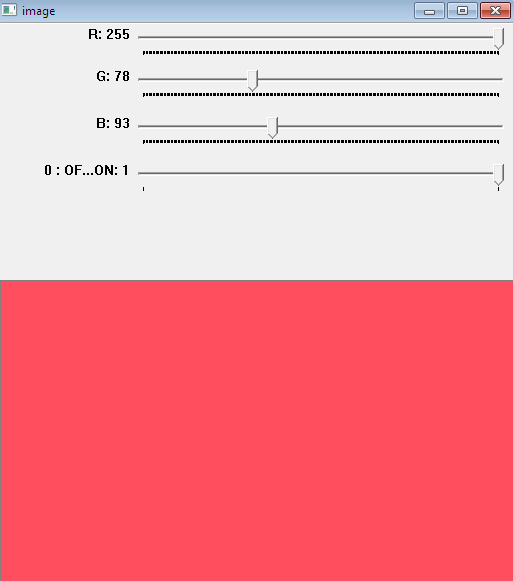

In [10]:
from IPython.display import Image
Image('F:/pictures1/p14.png')

##  تمرين: 

*انشئ تطبيق (رسام)مع لون محدد واداة رسم ذات قطر متغير بوساطة لوح تعديل . وذلك عبر الفأرة*
